In [1]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = y_train.reshape(-1,1).astype(np.float32)
y_test = y_test.reshape(-1,1).astype(np.float32)

# For hinge loss: convert labels to -1/+1
y_train_hinge = np.where(y_train==0, -1, 1)
y_test_hinge = np.where(y_test==0, -1, 1)

In [3]:
def sigmoid(x): return 1/(1+np.exp(-x))
def dsigmoid(y): return y*(1-y)

def tanh(x): return np.tanh(x)
def dtanh(y): return (1-y**2)

def relu(x): return np.maximum(0, x)
def drelu(x): return (x>0).astype(np.float32)

In [4]:
activations = {
    'relu': (relu, drelu),
    'tanh': (tanh, dtanh),
    'sigmoid': (sigmoid, dsigmoid)
}

In [5]:
def bce_loss(y_true,y_pred):
    eps = 1e-7
    return -np.mean(y_true*np.log(y_pred+eps) + (1-y_true)*np.log(1-y_pred+eps))

def mse_loss(y_true, y_pred):
    return np.mean((y_true-y_pred)**2)

def hinge_loss(y_true, y_pred):
    return np.mean(np.maximum(0, 1 - y_true*y_pred))

losses = {
    'bce': bce_loss,
    'mse': mse_loss,
    'hinge': hinge_loss
}


In [6]:
input_dim = X_train.shape[1]
hidden1 = 32
hidden2 = 16
output_dim = 1
lr = 0.01
epochs = 1000

results = []


In [7]:
for act_name , (act_fn, dact_fn) in activations.items():
    for loss_name , loss_fn in losses.items():
        np.random.seed(42)
        W1=np.random.randn(input_dim,hidden1) * 0.1
        b1=np.zeros((1,hidden1))
        W2= np.random.randn(hidden1, hidden2) * 0.1
        b2 = np.zeros((1, hidden2))
        W3 = np.random.randn(hidden2, output_dim) * 0.1
        b3 = np.zeros((1, output_dim))

        if loss_name=="hinge":
            y_true_train = y_train_hinge
            y_true_test = y_test_hinge
            output_fn = lambda x: x  # linear output
        
        else:
            y_true_train = y_train
            y_true_test = y_test
            output_fn = sigmoid

        for epoch in range(epochs):
            Z1=X_train@W1 + b1
            A1=act_fn(Z1)
            Z2=A1 @ W2 + b2
            A2 = act_fn(Z2)
            Z3 = A2 @ W3 + b3
            y_pred = output_fn(Z3)

            loss = loss_fn(y_true_train, y_pred)

            if loss_name=='bce':
                dZ3 = (y_pred - y_true_train)/y_true_train.shape[0]
            elif loss_name=='mse':
                dZ3 = 2*(y_pred - y_true_train)/y_true_train.shape[0] * dsigmoid(y_pred)
            else:  # hinge
                dZ3 = np.where(1 - y_true_train * y_pred > 0, -y_true_train/y_true_train.shape[0], 0)

            dW3 = A2.T @ dZ3
            db3 = np.sum(dZ3, axis=0, keepdims=True)

            dA2 = dZ3 @ W3.T
            dZ2 = dA2 * dact_fn(A2)

            dW2 = A1.T @ dZ2
            db2 = np.sum(dZ2, axis=0, keepdims=True)

            dA1 = dZ2 @ W2.T
            dZ1 = dA1 * dact_fn(A1)

            dW1 = X_train.T @ dZ1
            db1 = np.sum(dZ1, axis=0, keepdims=True)

            W3 -= lr*dW3
            b3 -= lr*db3
            W2 -= lr*dW2
            b2 -= lr*db2
            W1 -= lr*dW1
            b1 -= lr*db1

        #Evaluate
        Z1=X_test @ W1 + b1
        A1=act_fn(Z1)
        Z2 = A1 @ W2 + b2
        A2 = act_fn(Z2)
        Z3 = A2 @ W3 + b3
        y_pred_test = output_fn(Z3)


        if loss_name=='hinge':
            y_pred_label = np.where(y_pred_test>=0,1,-1)
        else:
            y_pred_label = (y_pred_test>0.5).astype(int)

        accuracy = np.mean(y_pred_label == y_true_test)
        results.append({
            'Activation': act_name,
            'Loss': loss_name,
            'Accuracy': round(accuracy,4)
        })

In [8]:
import pandas as pd
df = pd.DataFrame(results)
print(df.sort_values(by='Accuracy', ascending=False))


  Activation   Loss  Accuracy
0       relu    bce    0.9912
5       tanh  hinge    0.9912
3       tanh    bce    0.9825
4       tanh    mse    0.9825
2       relu  hinge    0.9737
1       relu    mse    0.9561
6    sigmoid    bce    0.6228
7    sigmoid    mse    0.6228
8    sigmoid  hinge    0.6228


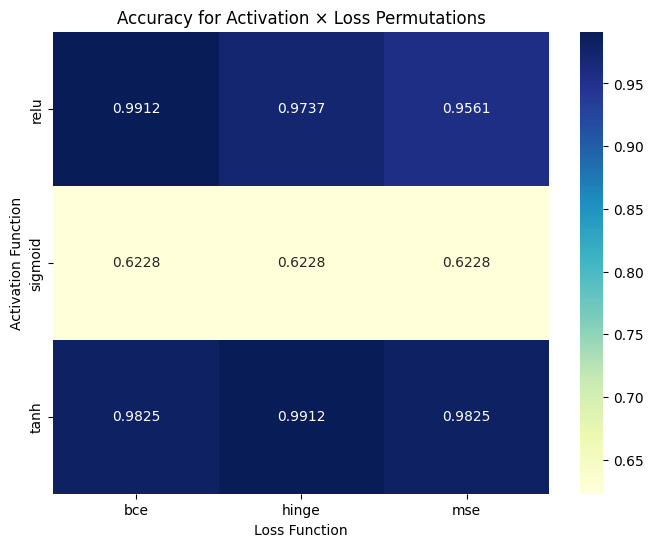

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert results to DataFrame
df = pd.DataFrame(results)

# Pivot table: rows = activation, columns = loss, values = accuracy
heatmap_data = df.pivot(index="Activation", columns="Loss", values="Accuracy")

plt.figure(figsize=(8,6))
sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="YlGnBu")
plt.title("Accuracy for Activation × Loss Permutations")
plt.ylabel("Activation Function")
plt.xlabel("Loss Function")
plt.show()
